
# Lab 6: CNNs: Classification, Verification


**Goal**: This notebook is designed to help you understand the fundamentals of Convolutional Neural Networks (CNNs).

**Lab workflow**:
- Go to **[Piazza post @453]**, CNN - Classification, Verification.
- Follow the instruction in this notebook and complete **checkpoints1-8**.
- By the end of the Lab, respond in **[]()** how many checkpoints you completed. It's not graded and designed to help you with your HWs.

**Presented by**:
- Pengyu Chang, IDL TA S26, pengyuch@andrew.cmu.edu
- Thomas Seleshi, IDL TA S26, tseleshi@andrew.cmu.edu

**Extra resources**: This Lab builds upon lectures 11 and 12.

**Plan**

In this exercise you will:
 - Review the core concepts behind CNNs focusing on face classification and verification
 - Implement a simple convolution operation from scratch
 - Build and train a CNN on the LFW dataset

Let's get started!

# checkpoint 1 ✅

# Go to piazza, make a copy of the notebook and let's get started!

<img src="https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExbGNoNHoyNjRxeWVsZTV0cnZoZnFscGttMWJ3eWRqOTR4eXpxamR2eiZlcD12MV9naWZzX3NlYXJjaCZjdD1n/8c3LWBENZHRnP6ixOc/giphy.gif" width="900">





![](https://example.com/image.gif)


# What is the difference bewteen classification and verfifcation?

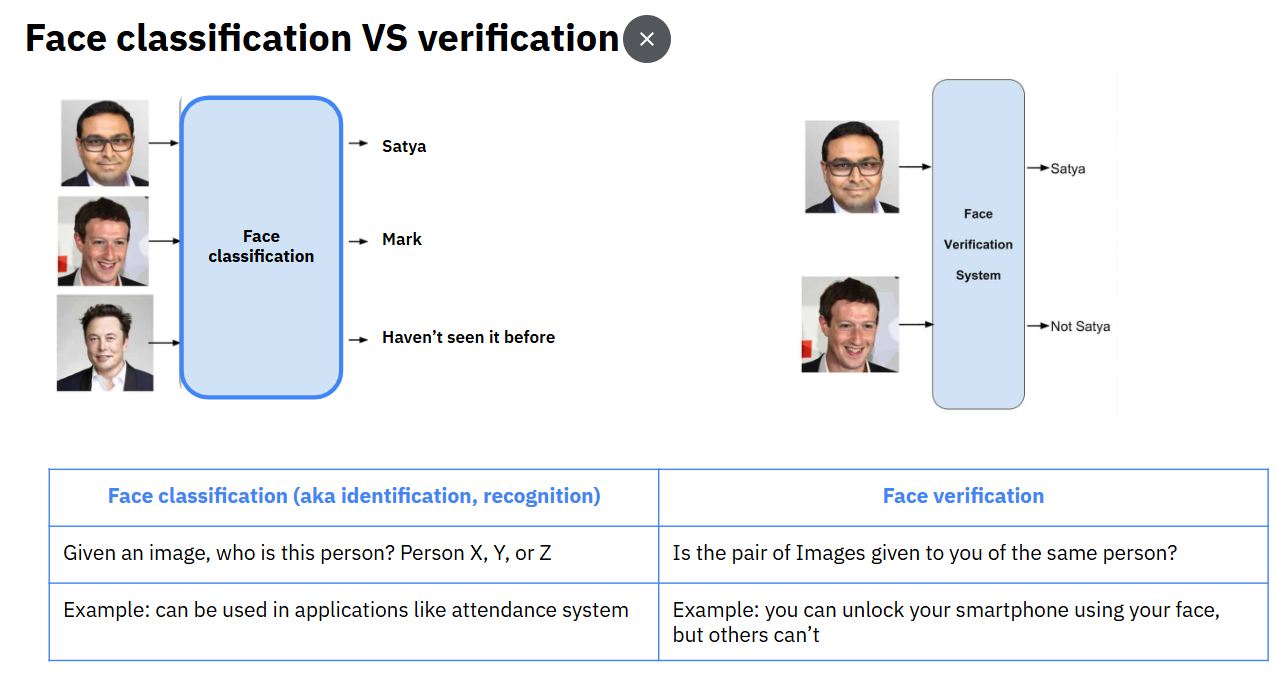

### checkpoint 2 ✅

check if you have a gpu

In [ ]:
#TODO: check if you have a gpu (bash command)
#________

Fri Feb 20 01:55:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
###############################################################################
# 1) SETUP AND LIBRARY IMPORTS
###############################################################################
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
import seaborn as sns
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### checkpoint 3 ✅

Input Image:
 [[1 2 3 0]
 [0 1 2 3]
 [3 0 1 2]
 [2 3 0 1]]
Kernel:
 [[ 1  0]
 [ 0 -1]]
Feature Map:
 [[-1. -2. -3.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [-3.  0.  0.  0.  3.]
 [-2.  0.  0.  0.  2.]
 [ 0.  2.  3.  0.  1.]]


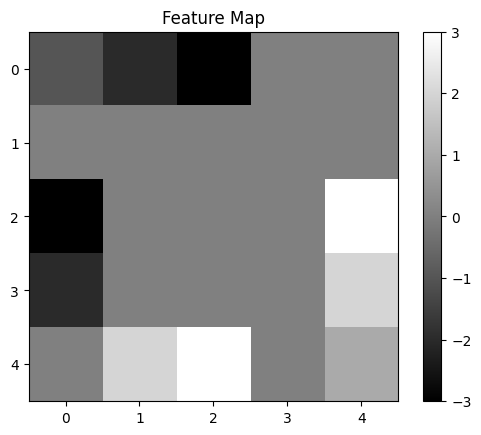

In [ ]:
def convolve2d(image, kernel, stride=1, padding=0): #input image and kernel, output is a feature map.
    # Add zero padding to the input image if needed
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    kernel_height, kernel_width = kernel.shape
    img_height, img_width = image.shape

    # Calculate output dimensions
    out_height = (img_height - kernel_height) // stride + 1
    out_width = (img_width - kernel_width) // stride + 1

    # Initialize output feature map
    output = np.zeros((out_height, out_width))

    # Perform the convolution
    for y in range(0, out_height):
        for x in range(0, out_width):
            # Extract the region of interest
            region = image[y*stride:y*stride+kernel_height, x*stride:x*stride+kernel_width]
            # TODO: Perform the convolution operation (Element-wise multiplication and Sum)
            output[y, x] = #______________
    return output

# Example usage for the convolution function
if __name__ == '__main__':
    # Define a simple image and kernel
    image = np.array([
        [1, 2, 3, 0],
        [0, 1, 2, 3],
        [3, 0, 1, 2],
        [2, 3, 0, 1]
    ])

    kernel = np.array([
        [1, 0],
        [0, -1]
    ])

    # Convolve the kernel over the image
    feature_map = convolve2d(image, kernel, stride=1, padding=1)
    print("Input Image:\n", image)
    print("Kernel:\n", kernel)
    print("Feature Map:\n", feature_map)

    # Visualize the feature map
    plt.figure()
    plt.imshow(feature_map, cmap='gray')
    plt.title('Feature Map')
    plt.colorbar()
    plt.show()

## How many classes are there in the dataset?

### checkpoint 4 ✅

In [ ]:
###############################################################################
# 2) LOAD THE LFW PEOPLE DATASET
###############################################################################
lfw = fetch_lfw_people(min_faces_per_person=50, resize=0.4)
X = lfw.images
y = lfw.target
target_names = lfw.target_names

print(f"Dataset shape: {X.shape}")
# TODO: Print the number of unique people (classes) in the dataset
# Hint: 'target_names' contains the list of names.
print(f"Number of classes: {_______}")
for name in target_names:
  print(f"Name:{name}")

Dataset shape: (1560, 50, 37)
Number of classes: 12
Name:Ariel Sharon
Name:Colin Powell
Name:Donald Rumsfeld
Name:George W Bush
Name:Gerhard Schroeder
Name:Hugo Chavez
Name:Jacques Chirac
Name:Jean Chretien
Name:John Ashcroft
Name:Junichiro Koizumi
Name:Serena Williams
Name:Tony Blair


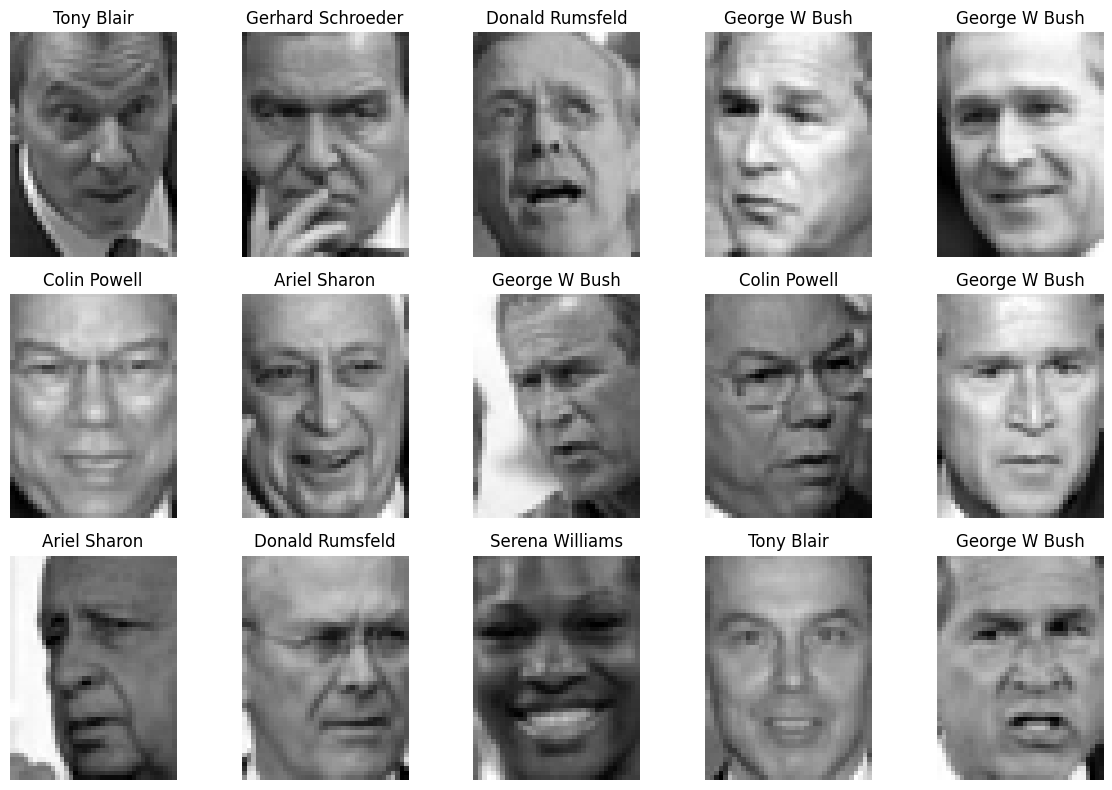

In [ ]:
###############################################################################
# 3) PLOT SOME SAMPLE IMAGES
###############################################################################
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.ravel()
for i in np.arange(15):
    axes[i].imshow(X[i], cmap='gray')
    axes[i].set_title(target_names[y[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
###############################################################################
# 4) PREPROCESSING AND TRAIN-TEST SPLIT
###############################################################################
# TODO: Normalize pixel values to be between 0 and 1
# Hint: The max pixel value in standard images is 255.
X = X.astype('float32') / _____

# TODO: Add the "Channel" dimension for PyTorch
# PyTorch expects (Batch, Channels, Height, Width). Currently we have (Batch, Height, Width).
# We need to insert a dimension at index 1.
if X.ndim == 3:
    X = np.expand_dims(X, _____)

# Split into training and testing sets
# Note: We keep y as integers (0, 1, 2...) because PyTorch CrossEntropyLoss expects class indices
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train.shape}")

Training samples: 1248, Test samples: 312
Image shape: (1248, 1, 50, 37)


In [ ]:
###############################################################################
# 5) DATA AUGMENTATION (Using Custom Dataset)
###############################################################################
class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Convert numpy to torch tensor
        img = torch.tensor(self.images[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        return img, label

# Define augmentations matching the original Keras logic
# Rotation, Shift (Affine), Flip
train_transforms = transforms.Compose([
    # TODO: Add a transformation to randomly flip the image horizontally with a possiblity of 0.2
    transforms.RandomHorizontalFlip(0.2),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomRotation(15),
])

# Create Datasets and Loaders
train_dataset = FaceDataset(X_train, y_train, transform=train_transforms)
test_dataset = FaceDataset(X_test, y_test, transform=None)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### checkpoint 5 ✅

In [ ]:
###############################################################################
# 6) BUILD THE CNN MODEL
###############################################################################
class FaceCNN(nn.Module):
    def __init__(self, num_classes):
        super(FaceCNN, self).__init__()

        # Convolutional Blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Flattening
        self.flatten = nn.Flatten()

        # Calculate the size after 3 pooling layers
        # Input: 50x37 -> Pool1: 25x18 -> Pool2: 12x9 -> Pool3: 6x4
        # 128 channels * 6 * 4 = 3072 features (approx, depends on exact padding/rounding)
        # We can use a dummy pass to find this number automatically, or calculate it.
        self._to_linear = None
        self._get_conv_output((1, X.shape[-2], X.shape[-1])) # Helper to calculate size

        # Dense Layers (Embedding & Output)
        self.fc_embedding = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU()
        )
        self.dropout = nn.Dropout(0.5)
        # TODO: Define the final classification layer
        # Input size is 128 (from embedding), Output size should be the number of people.
        self.fc_output = nn.Linear(128, ______)

    def _get_conv_output(self, shape):
        # Helper function to auto-calculate flat size
        with torch.no_grad():
            input = torch.zeros(1, *shape)
            output = self.conv1(input)
            output = self.conv2(output)
            output = self.conv3(output)
            self._to_linear = int(np.prod(output.size()))

    def forward(self, x):
        # Feature Extraction
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = self.flatten(x)

        # Embedding
        embedding = self.fc_embedding(x)

        # Classification
        out = self.dropout(embedding)
        logits = self.fc_output(out)

        # Return BOTH logits (for training) and embedding (for verification)
        return logits, embedding

model = FaceCNN(num_classes=len(target_names)).to(device)
print(model)

FaceCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_embedding): Sequential(
    (0): Linear(in_features=3072, out_fea

### checkpoint 6 ✅

In [ ]:
criterion = nn.CrossEntropyLoss() # Combines Softmax and NLLLoss
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9) # this is SGD with momentum, when you train your HW2P2, different optimizer might greatly influence your training! So be aware when picking your optimizer.
def train_model(num_epochs):
    best_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training Loop
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs, _ = model(images) # We ignore embedding during training
            loss = criterion(outputs, labels)
            # TODO: Perform Backpropagation
            # Hint: This calculates the gradients
            loss.backward()


            # TODO: Update the model weights
            # Hint: The optimizer takes a 'step'
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        # Validation Loop
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs, _ = model(images)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_face_model_pytorch.pth')

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, '
              f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

train_model(num_epochs=100)

Epoch [1/100], Loss: 2.2586, Train Acc: 29.17%, Val Acc: 34.29%
Epoch [2/100], Loss: 2.1527, Train Acc: 33.73%, Val Acc: 34.29%
Epoch [3/100], Loss: 2.1138, Train Acc: 33.09%, Val Acc: 34.29%
Epoch [4/100], Loss: 2.0725, Train Acc: 34.54%, Val Acc: 35.26%
Epoch [5/100], Loss: 2.0043, Train Acc: 35.74%, Val Acc: 41.03%
Epoch [6/100], Loss: 2.0093, Train Acc: 35.02%, Val Acc: 35.90%
Epoch [7/100], Loss: 1.9759, Train Acc: 35.66%, Val Acc: 39.42%
Epoch [8/100], Loss: 1.8968, Train Acc: 36.94%, Val Acc: 38.46%
Epoch [9/100], Loss: 1.8600, Train Acc: 42.95%, Val Acc: 48.72%
Epoch [10/100], Loss: 1.8107, Train Acc: 43.59%, Val Acc: 45.83%
Epoch [11/100], Loss: 1.8227, Train Acc: 42.63%, Val Acc: 49.36%
Epoch [12/100], Loss: 1.8009, Train Acc: 42.71%, Val Acc: 48.72%
Epoch [13/100], Loss: 1.7949, Train Acc: 42.15%, Val Acc: 49.68%
Epoch [14/100], Loss: 1.7418, Train Acc: 43.99%, Val Acc: 49.04%
Epoch [15/100], Loss: 1.7399, Train Acc: 43.91%, Val Acc: 41.03%
Epoch [16/100], Loss: 1.7586, Trai

### checkpoint 7 ✅

In [ ]:
###############################################################################
# 8) LOAD BEST MODEL AND EXTRACT EMBEDDINGS
###############################################################################
# Load the best saved weights
model.load_state_dict(torch.load('best_face_model_pytorch.pth'))
model.eval()

# Get embeddings for first 10 test images
sample_imgs = torch.tensor(X_test[:10], dtype=torch.float32).to(device)
with torch.no_grad():
    _, sample_embeddings = model(sample_imgs)

print("Embeddings shape:", sample_embeddings.shape)

Embeddings shape: torch.Size([10, 128])


### checkpoint 8 ✅

In [ ]:
###############################################################################
# 9) DEMO VERIFICATION (WITH 2 RANDOM IMAGES)
###############################################################################
import numpy as np # Ensure numpy is imported
def cosine_similarity(a,b):
  # TODO: return cosine similarty of a and b
  # return _______ / _____ * _____
# 1. Pick two random indices from the test set size
idx1 = np.random.randint(0, len(X_test))
idx2 = np.random.randint(0, len(X_test))

# Make sure we didn't accidentally pick the exact same image twice (unlikely but possible)
while idx1 == idx2:
    idx2 = np.random.randint(0, len(X_test))

print(f"Randomly selected indices: {idx1} and {idx2}")

# 2. Get the Ground Truth (Real Answer)
label1 = y_test[idx1]
label2 = y_test[idx2]
name1 = target_names[label1]
name2 = target_names[label2]

print(f"Image 1 is: {name1}")
print(f"Image 2 is: {name2}")

if label1 == label2:
    print("GROUND TRUTH: SAME PERSON")
else:
    print("GROUND TRUTH: DIFFERENT PERSONS")

# 3. Prepare the images for the model
img1 = torch.tensor(X_test[idx1], dtype=torch.float32).unsqueeze(0).to(device)
img2 = torch.tensor(X_test[idx2], dtype=torch.float32).unsqueeze(0).to(device)

# 4. Run Model
with torch.no_grad():
    _, embed1 = model(img1)
    _, embed2 = model(img2)

sim = cosine_similarity(embed1.squeeze(), embed2.squeeze())
print(f"Model Similarity Score: {sim:.3f}")

threshold = 0.75
if sim > threshold:
    print("MODEL PREDICTION: Same Person")
else:
    print("MODEL PREDICTION: Different Persons")

Randomly selected indices: 208 and 135
Image 1 is: Donald Rumsfeld
Image 2 is: Tony Blair
GROUND TRUTH: DIFFERENT PERSONS
Model Similarity Score: 0.394
MODEL PREDICTION: Different Persons
